# Clustering 

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import pickle
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from functions import *
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
with open('processed_data.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

X_scaled = loaded_data['X_scaled']
habit_features = loaded_data['feature_names']
df = loaded_data['original_df']

print(f"Ready to cluster {X_scaled.shape[0]} rows with {len(habit_features)} features.")

Ready to cluster 2000 rows with 8 features.


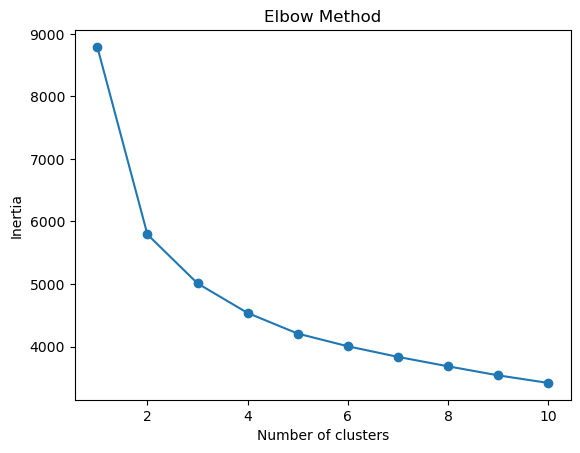

In [28]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [29]:
print("Inertia values:", [round(x, 2) for x in inertia])

Inertia values: [8790.4, 5792.09, 5010.4, 4537.46, 4207.91, 4005.31, 3835.69, 3684.83, 3540.35, 3419.29]


By the elbow curve, the suggested number of clusters could be 3 (or 4).

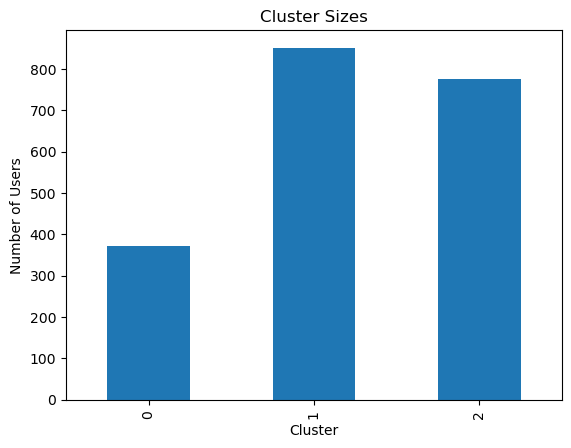

In [30]:
kmeans_3 = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans_3.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df['cluster_kmeans'] = clusters

df.groupby('cluster_kmeans').size().plot(kind='bar')
plt.title('Cluster Sizes')
plt.xlabel('Cluster')
plt.ylabel('Number of Users')
plt.show()

Cluster centroids (mean values for each feature):
                work_hours  meetings_count  breaks_taken  after_hours_work  \
cluster_kmeans                                                               
0                11.574531        7.533512      3.672922          0.372654   
1                 7.766686        2.676851      6.505288          0.091657   
2                 9.001598        3.052835      4.157216          0.123711   

                app_switches  sleep_hours  task_completion  isolation_index  
cluster_kmeans                                                               
0                  86.305630     5.539625        66.984638         6.442359  
1                  44.820212     7.280270        87.590376         4.713278  
2                  53.759021     7.123724        78.165799         4.300258  


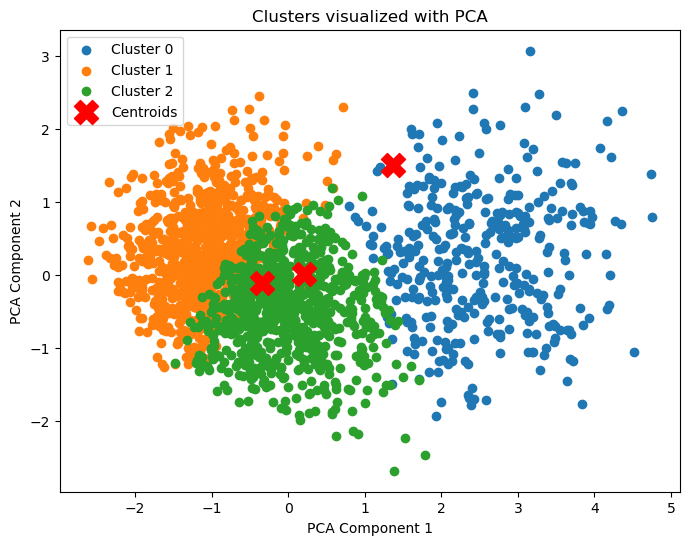

In [32]:
cluster_summary = df.groupby('cluster_kmeans')[habit_features].mean()
print("Cluster centroids (mean values for each feature):")
print(cluster_summary)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
for cluster in range(3):
    plt.scatter(X_pca[clusters == cluster, 0], X_pca[clusters == cluster, 1], label=f'Cluster {cluster}')
plt.scatter(kmeans_3.cluster_centers_[:, 0], kmeans_3.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title('Clusters visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()